In [ ]:
!pip install Biopython

     |████████████████████████████████| 2.3MB 17.5MB/s 


In [ ]:
import tarfile
import pandas as pd
import numpy as np
import re
from datetime import datetime

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from keras.wrappers.scikit_learn import KerasClassifier

from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Dropout, Activation, Flatten
from keras.layers import Embedding, LSTM, Dense, Bidirectional

from matplotlib import pyplot as plt

from Bio.Seq import Seq

### Read data

In [ ]:
filename = "training_data.tar.gz"

data = tarfile.open(filename, "r:gz")
data.extractall()
data.close()

In [ ]:
b = open('ghl_gold.fa','r')
bind = b.readlines()
b.close()

u = open('ghl_gold_random.fa','r')
unbind = u.readlines()
u.close()

### Data preprocessing

In [ ]:
bind = [v for v in bind if '>' not in v]
bind = [s.replace('\n', '') for s in bind]
bind = [x.upper() for x in bind]

unbind = [v for v in unbind if '>' not in v]
unbind = [s.replace('\n', '') for s in unbind]
unbind = [x.upper() for x in unbind]

In [ ]:
print(len(bind), len(unbind))

1400090 1400090


Reverse Complement

In [ ]:
bind_rev = list(range(len(bind)))

for i in range(len(bind)):
  seq = Seq(bind[i])
  rev = seq.reverse_complement()
  bind_rev[i] = str(rev)

unbind_rev = list(range(len(unbind)))

for i in range(len(unbind)):
  seq = Seq(unbind[i])
  rev = seq.reverse_complement()
  unbind_rev[i] = str(rev)

In [ ]:
bind_fb = bind + bind_rev
unbind_fb = unbind + unbind_rev

word embedding

divide sequences (originally 20bp long) into k-mers (7-mers long)

In [ ]:
def getKmers(seq, kmer):
    return [seq[x:x+kmer].upper() for x in range(len(seq) - kmer + 1)]

kmer = 7

bind_kmers = [' '.join(getKmers(i, kmer)) for i in bind_fb]
unbind_kmers = [' '.join(getKmers(i, kmer)) for i in unbind_fb]

total_kmers = bind_kmers + unbind_kmers

convert each kmer into integer

In [ ]:
from keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(total_kmers)
encoded_kmers = tokenizer.texts_to_sequences(total_kmers) #text_to_matrix (one-hot encoding)

vocab_size = len(tokenizer.word_index) + 1

generate dataframe

In [ ]:
bind_label = [1 for i in range(len(bind_kmers))]
unbind_label = [0 for i in range(len(unbind_kmers))]

In [ ]:
df = pd.DataFrame({"seq": encoded_kmers, "label":bind_label + unbind_label})

In [ ]:
df.head()

,seq,label
0,"[9243, 10915, 10141, 11391, 6765, 9107, 5323, ...",1
1,"[5147, 7303, 11333, 15863, 14125, 15979, 15451...",1
2,"[6121, 7087, 11151, 10109, 9159, 5537, 4673, 1...",1
3,"[11435, 12043, 12781, 15129, 14499, 14805, 137...",1
4,"[14405, 14789, 12085, 11011, 6645, 8589, 6015,...",1


##### split the dataset

In [ ]:
from sklearn.utils import shuffle

new_df = shuffle(df)
new_df = new_df.reset_index()

In [ ]:
x = new_df.seq
y = new_df.label

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

In [ ]:
x_train = np.asarray(x_train.values.tolist())
y_train = np.asarray(y_train.values.tolist())

x_test = np.asarray(x_test.values.tolist())
y_test = np.asarray(y_test.values.tolist())

### RNN model

LSTM

In [ ]:
model = Sequential()
model.add(Embedding(vocab_size, 10, input_length=14))
model.add(LSTM(10))
model.add(Dense(10, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_5 (Embedding)      (None, 14, 10)            335440    
_________________________________________________________________
lstm_5 (LSTM)                (None, 10)                840       
_________________________________________________________________
dense_10 (Dense)             (None, 10)                110       
_________________________________________________________________
dropout_5 (Dropout)          (None, 10)                0         
_________________________________________________________________
dense_11 (Dense)             (None, 1)                 11        
Total params: 336,401
Trainable params: 336,401
Non-trainable params: 0
_________________________________________________________________


In [ ]:
history = model.fit(x_train, y_train, epochs = 10, validation_split = 0.2)

Epoch 1/10
112008/112008 [==============================] - 838s 7ms/step - loss: 0.3604 - accuracy: 0.8432 - val_loss: 0.3253 - val_accuracy: 0.8579
Epoch 2/10
112008/112008 [==============================] - 813s 7ms/step - loss: 0.3260 - accuracy: 0.8607 - val_loss: 0.3213 - val_accuracy: 0.8599
Epoch 3/10
112008/112008 [==============================] - 816s 7ms/step - loss: 0.3206 - accuracy: 0.8632 - val_loss: 0.3206 - val_accuracy: 0.8606
Epoch 4/10
112008/112008 [==============================] - 779s 7ms/step - loss: 0.3170 - accuracy: 0.8647 - val_loss: 0.3209 - val_accuracy: 0.8601
Epoch 5/10
112008/112008 [==============================] - 806s 7ms/step - loss: 0.3141 - accuracy: 0.8664 - val_loss: 0.3201 - val_accuracy: 0.8606
Epoch 6/10
112008/112008 [==============================] - 827s 7ms/step - loss: 0.3133 - accuracy: 0.8667 - val_loss: 0.3231 - val_accuracy: 0.8603
Epoch 7/10
112008/112008 [==============================] - 855s 8ms/step - loss: 0.3120 - accuracy:

BiLSTM

In [ ]:
bi_model = Sequential()
bi_model.add(Embedding(vocab_size, 10))
bi_model.add(Bidirectional(LSTM(10)))
bi_model.add(Dense(10, activation='relu'))
bi_model.add(Dropout(0.2))
bi_model.add(Dense(1, activation='sigmoid'))
bi_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
bi_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, None, 10)          335440    
_________________________________________________________________
bidirectional (Bidirectional (None, 20)                1680      
_________________________________________________________________
dense (Dense)                (None, 10)                210       
_________________________________________________________________
dropout (Dropout)            (None, 10)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 11        
Total params: 337,341
Trainable params: 337,341
Non-trainable params: 0
_________________________________________________________________


In [ ]:
bi_history = bi_model.fit(x_train, y_train, epochs = 10, validation_split = 0.2)

Epoch 1/10
112008/112008 [==============================] - 1016s 9ms/step - loss: 0.3593 - accuracy: 0.8423 - val_loss: 0.3233 - val_accuracy: 0.8588
Epoch 2/10
112008/112008 [==============================] - 978s 9ms/step - loss: 0.3220 - accuracy: 0.8615 - val_loss: 0.3176 - val_accuracy: 0.8613
Epoch 3/10
112008/112008 [==============================] - 967s 9ms/step - loss: 0.3147 - accuracy: 0.8650 - val_loss: 0.3173 - val_accuracy: 0.8613
Epoch 4/10
112008/112008 [==============================] - 956s 9ms/step - loss: 0.3122 - accuracy: 0.8666 - val_loss: 0.3174 - val_accuracy: 0.8614
Epoch 5/10
112008/112008 [==============================] - 957s 9ms/step - loss: 0.3094 - accuracy: 0.8678 - val_loss: 0.3180 - val_accuracy: 0.8611
Epoch 6/10
112008/112008 [==============================] - 957s 9ms/step - loss: 0.3081 - accuracy: 0.8687 - val_loss: 0.3195 - val_accuracy: 0.8614
Epoch 7/10
112008/112008 [==============================] - 970s 9ms/step - loss: 0.3069 - accuracy

##### Evaluation

Accuracy

In [ ]:
score = model.evaluate(x_test, y_test)
print("score = " + str(round(score[1],2)))

35003/35003 [==============================] - 78s 2ms/step - loss: 0.3222 - accuracy: 0.8599
score = 0.86


In [ ]:
bi_score = bi_model.evaluate(x_test, y_test)
print("score = " + str(round(bi_score[1],2)))

35003/35003 [==============================] - 96s 3ms/step - loss: 0.3200 - accuracy: 0.8608
score = 0.86


loss-epoch curve

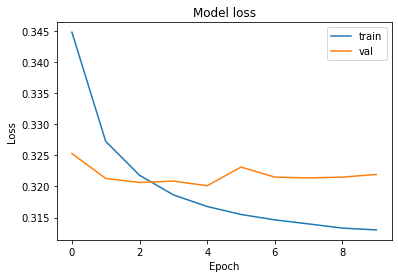

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

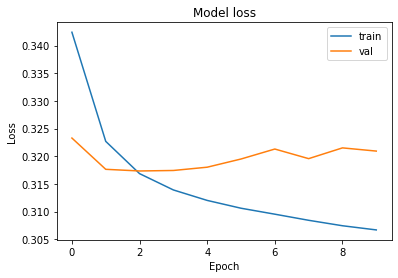

In [ ]:
plt.plot(bi_history.history['loss'])
plt.plot(bi_history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

precision-recall curve

In [ ]:
probs = model.predict(x_test_test)
bi_probs = bi_model.predict(x_test)

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, probs)
bi_precision, bi_recall, bi_thresholds = precision_recall_curve(y_test, bi_probs)

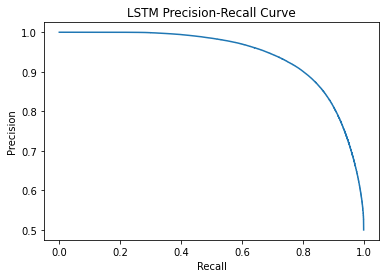

In [ ]:
plt.plot(recall, precision)

plt.title('LSTM Precision-Recall Curve')

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.show()

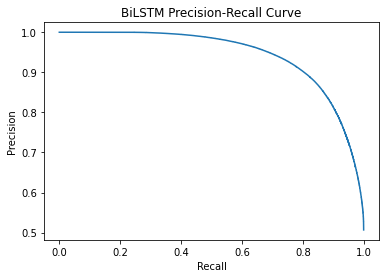

In [ ]:
plt.plot(bi_recall, bi_precision)

plt.title('BiLSTM Precision-Recall Curve')

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.show()

ROC curve & AUC

In [ ]:
auc = roc_auc_score(y_test, probs)
fpr, tpr, _ = roc_curve(y_test, probs)

bi_auc = roc_auc_score(y_test, bi_probs)
bi_fpr, bi_tpr, bi_ = roc_curve(y_test, bi_probs)

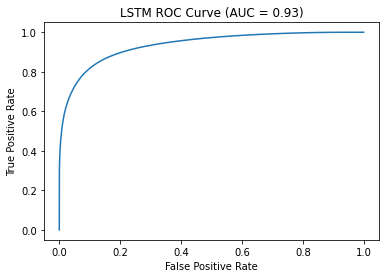

In [ ]:
plt.plot(fpr, tpr)
plt.title('LSTM ROC Curve (AUC = ' + str(round(auc,2)) + ')')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

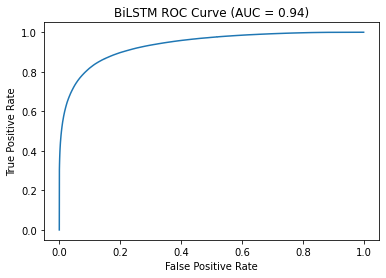

In [ ]:
plt.plot(bi_fpr, bi_tpr)
plt.title('BiLSTM ROC Curve (AUC = ' + str(round(bi_auc,2)) + ')')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

save the result

In [ ]:
result_dict = {'accuracy': score[1], 'loss': history.history['loss'], 'val_loss': history.history['val_loss'],
               'precision': precision, 'recall': recall, 'tpr': tpr, 'fpr': fpr, 'auc': auc}
result_df = pd.DataFrame({ key:pd.Series(value) for key, value in result_dict.items() })
result_df.head()

,accuracy,loss,val_loss,precision,recall,tpr,fpr,auc
0,0.859903,0.344799,0.325290,0.500224,1.000000,0.000000,0.0,0.934501
1,NaN,0.327238,0.321284,0.500224,0.999998,0.000054,0.0,NaN
2,NaN,0.321795,0.320636,0.500224,0.999998,0.000059,0.0,NaN
3,NaN,0.318644,0.320857,0.500226,0.999998,0.000889,0.0,NaN
4,NaN,0.316770,0.320116,0.500226,0.999998,0.003036,0.0,NaN


In [ ]:
result_df.to_csv ('LSTM_Emb_result.csv', index = False, header=True)

In [ ]:
bi_result_dict = {'accuracy': bi_score[1], 'loss': bi_history.history['loss'], 'val_loss': bi_history.history['val_loss'],
               'precision': bi_precision, 'recall': bi_recall, 'tpr': bi_tpr, 'fpr': bi_fpr, 'auc': bi_auc}
bi_result_df = pd.DataFrame({ key:pd.Series(value) for key, value in bi_result_dict.items() })
bi_result_df.head()

,accuracy,loss,val_loss,precision,recall,tpr,fpr,auc
0,0.860789,0.342405,0.323293,0.506835,1.000000,0.000000,0.0,0.935477
1,NaN,0.322696,0.317648,0.506835,0.999998,0.000705,0.0,NaN
2,NaN,0.316868,0.317347,0.506841,0.999998,0.007706,0.0,NaN
3,NaN,0.313920,0.317437,0.506841,0.999998,0.008645,0.0,NaN
4,NaN,0.312030,0.318029,0.506842,0.999998,0.010706,0.0,NaN


In [ ]:
bi_result_df.to_csv ('BiLSTM_Emb_result.csv', index = False, header=True)